In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv(r'C:\Users\2k-tech\Data Analyst\Project 3\airbnb_market_data.csv')

# Clean price column
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Inspect summary statistics
print(df.groupby('room_type')['price'].describe())

                 count        mean         std     min      25%      50%  \
room_type                                                                  
Entire home/apt  634.0  226.322808   96.552751   49.20  159.405  208.010   
Hotel room        21.0  265.347619  132.849859  106.36  163.810  265.200   
Private room     495.0  110.931717   48.975476   25.00   74.870  102.440   
Shared room       50.0   54.589600   25.247427   25.00   39.565   49.075   

                     75%     max  
room_type                         
Entire home/apt  275.185  710.46  
Hotel room       291.850  640.60  
Private room     137.500  345.25  
Shared room       60.135  164.50  


C:\Users\2k-tech\AppData\Local\Temp\ipykernel_8048\2247652952.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="room_type", y="price", palette="Set2")


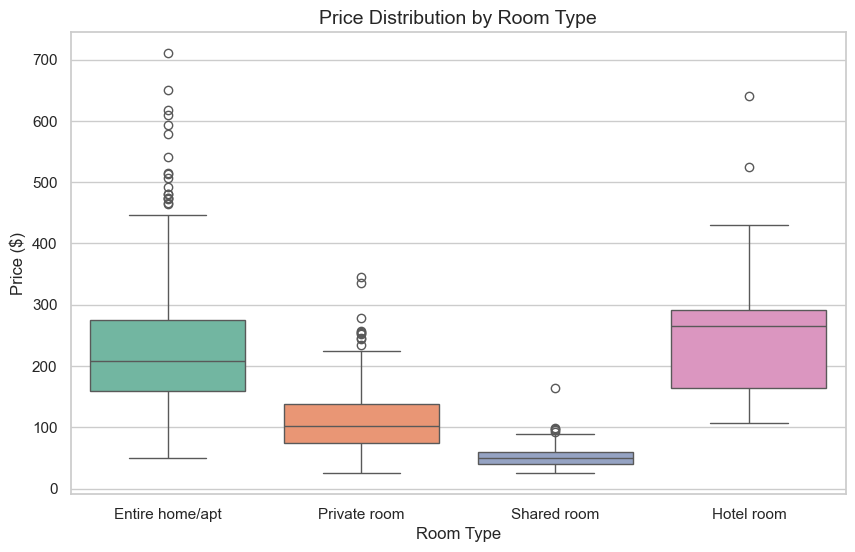

Missing values per column:
id                         0
host_id                    0
host_is_superhost          0
neighbourhood_group        0
neighbourhood_cleansed     0
latitude                   0
longitude                  0
room_type                  0
accommodates               0
bedrooms                   0
bathrooms                  0
price                      0
minimum_nights             0
number_of_reviews          0
reviews_per_month         26
review_scores_rating       0
availability_365           0
dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# 1. Visualize price distribution by room type (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="room_type", y="price", palette="Set2")
plt.title("Price Distribution by Room Type", fontsize=14)
plt.xlabel("Room Type", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.show()

# 2. Check missing values across the dataset
print("Missing values per column:")
print(df.isnull().sum())

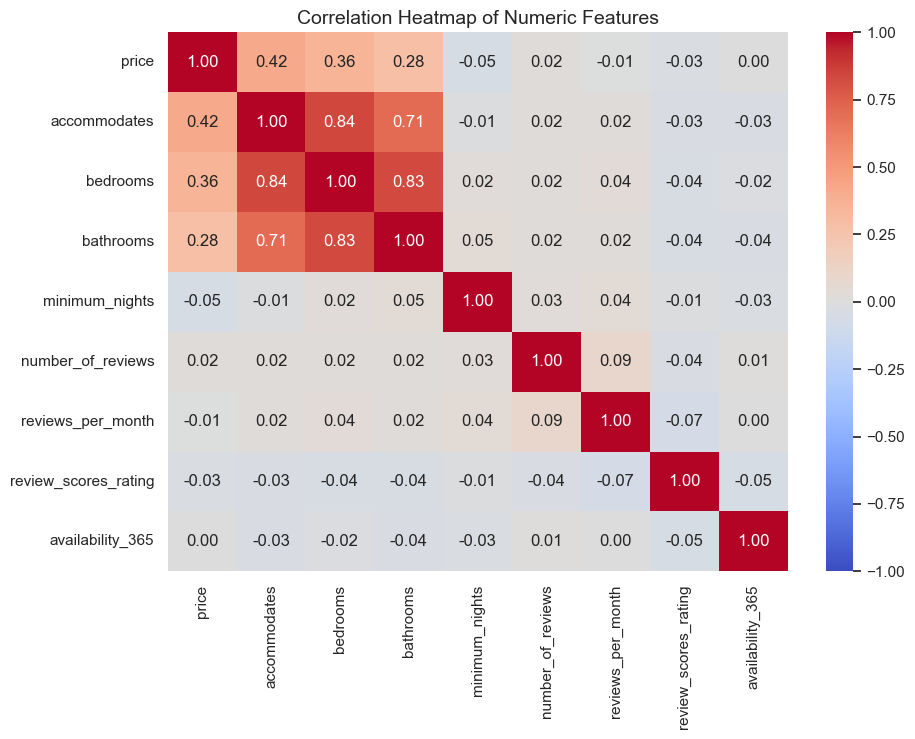

In [6]:
# 1. Fill missing values in reviews_per_month with 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 2. Select numeric columns for correlation analysis
numeric_cols = [
    'price', 'accommodates', 'bedrooms', 'bathrooms', 
    'minimum_nights', 'number_of_reviews', 'reviews_per_month', 
    'review_scores_rating', 'availability_365'
]

# 3. Compute and plot correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_cols].corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmax=1, 
    vmin=-1
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.show()

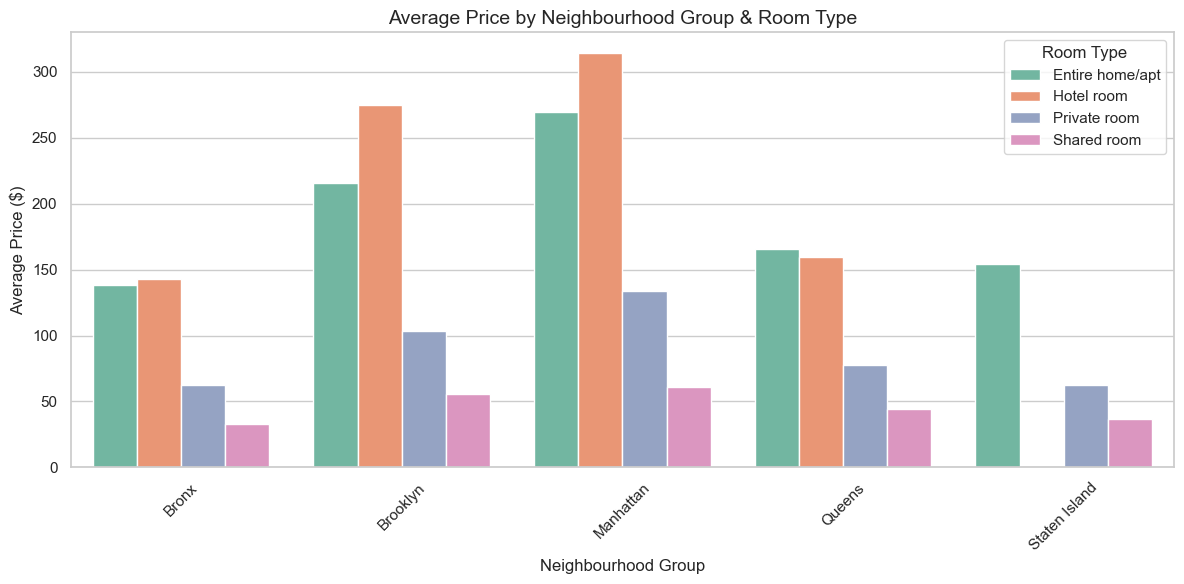

In [7]:
# 1. Calculate average price by neighbourhood group and room type
location_price = df.groupby(['neighbourhood_group', 'room_type'])['price'].mean().reset_index()

# 2. Visualize average price variations
plt.figure(figsize=(12, 6))
sns.barplot(data=location_price, x='neighbourhood_group', y='price', hue='room_type', palette='Set2')
plt.title('Average Price by Neighbourhood Group & Room Type', fontsize=14)
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()

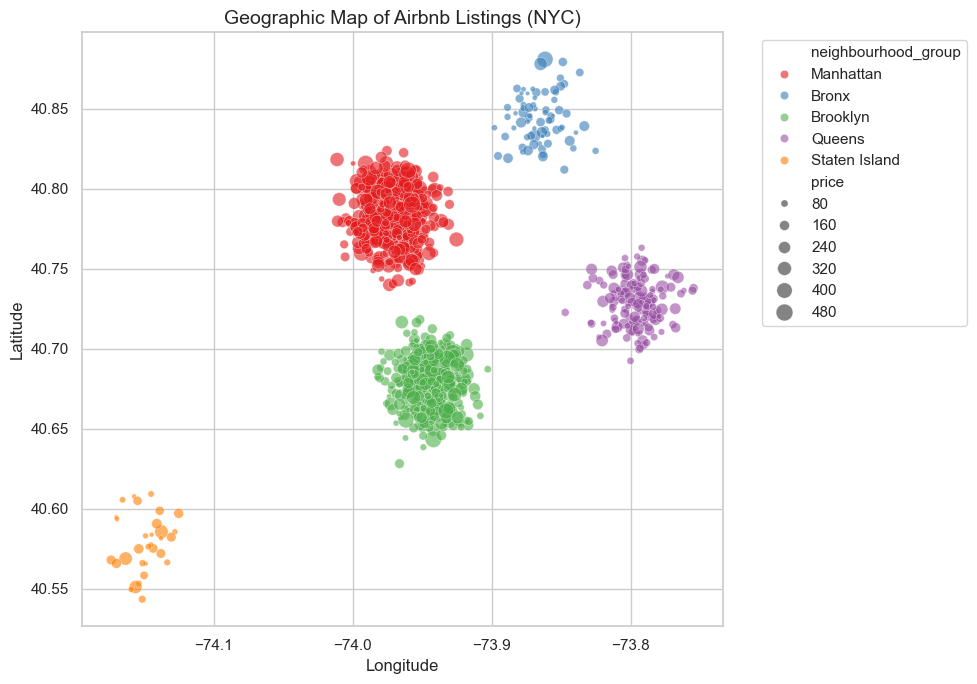

In [8]:
# 1. Geographic map of listings filtered below $500 for visual clarity
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df[df['price'] < 500], 
    x='longitude', 
    y='latitude', 
    hue='neighbourhood_group', 
    size='price', 
    sizes=(10, 150), 
    alpha=0.6, 
    palette='Set1'
)
plt.title('Geographic Map of Airbnb Listings (NYC)', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\2k-tech\AppData\Local\Temp\ipykernel_8048\337332025.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_neighbourhoods, x='price', y=neigh_col, palette='Blues_r')


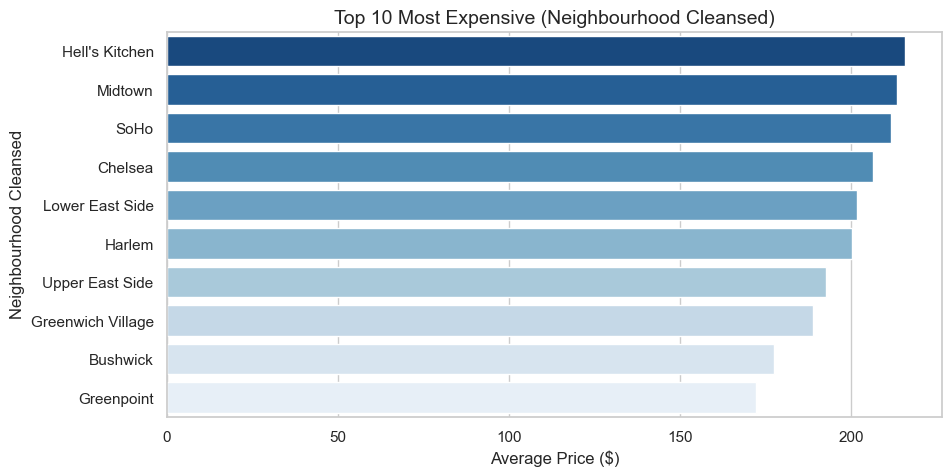

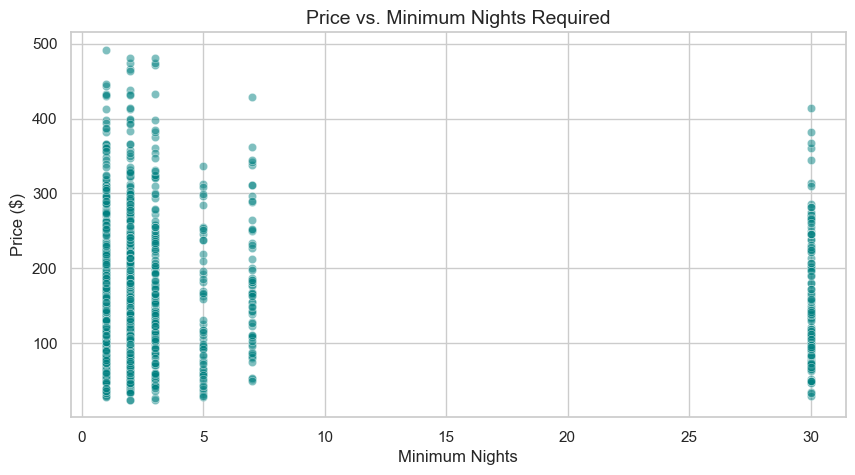

In [10]:
# Check which neighborhood column exists in your DataFrame
neigh_col = next((col for col in ['neighbourhood', 'neighborhood', 'neighbourhood_cleansed'] if col in df.columns), 'neighbourhood_group')

# 1. Top 10 Most Expensive Neighbourhoods (min. 5 listings)
top_neighbourhoods = (
    df.groupby(neigh_col)
    .filter(lambda x: len(x) >= 5)
    .groupby(neigh_col)['price']
    .mean()
    .nlargest(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_neighbourhoods, x='price', y=neigh_col, palette='Blues_r')
plt.title(f'Top 10 Most Expensive ({neigh_col.replace("_", " ").title()})', fontsize=14)
plt.xlabel('Average Price ($)', fontsize=12)
plt.ylabel(neigh_col.replace('_', ' ').title(), fontsize=12)
plt.show()

# 2. Minimum Nights vs. Price Relationship
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df[df['price'] < 500], x='minimum_nights', y='price', alpha=0.5, color='teal')
plt.title('Price vs. Minimum Nights Required', fontsize=14)
plt.xlabel('Minimum Nights', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.show()

In [11]:
# 1. Feature Engineering: Create a log-transformed price to handle right-skewness
import numpy as np

df['log_price'] = np.log1p(df['price'])

# 2. Select key features for predictive modeling
features = ['room_type', 'neighbourhood_group', 'accommodates', 'bedrooms', 
            'bathrooms', 'minimum_nights', 'availability_365', 'reviews_per_month']

# Filter df to available columns
available_features = [col for col in features if col in df.columns]

# 3. Create One-Hot Encoded features for ML models
X = pd.get_dummies(df[available_features], drop_first=True)
y = df['log_price']

print("Features processed successfully!")
print(f"Dataset shape for modeling: {X.shape}")
X.head()

Features processed successfully!
Dataset shape for modeling: (1200, 13)


,accommodates,bedrooms,bathrooms,minimum_nights,availability_365,reviews_per_month,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,4,3,2.2,5,229,1.20,False,False,False,False,True,False,False
1,4,2,1.5,1,104,1.32,False,False,False,False,False,False,False
2,2,1,1.0,1,208,1.51,False,True,False,True,False,False,False
3,4,2,2.0,3,61,3.17,False,False,False,True,False,False,False
4,2,1,1.5,2,239,0.67,False,True,False,False,True,False,False


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Predict on test set
y_pred_log = model.predict(X_test)

# 4. Convert predictions back to original dollar scale for evaluation
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

# 5. Evaluate Performance
r2 = r2_score(y_test, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print(f"Model Performance Metrics:")
print(f"--------------------------")
print(f"R² Score (log scale): {r2:.3f}")
print(f"RMSE (actual price scale): ${rmse:.2f}")

Model Performance Metrics:
--------------------------
R² Score (log scale): 0.587
RMSE (actual price scale): $85.44


C:\Users\2k-tech\AppData\Local\Temp\ipykernel_8048\2617615910.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


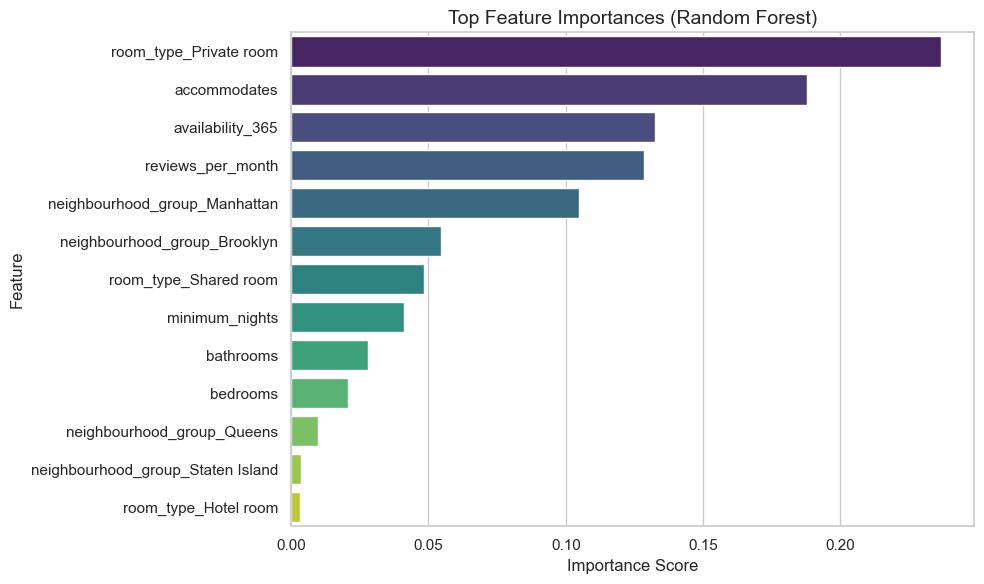

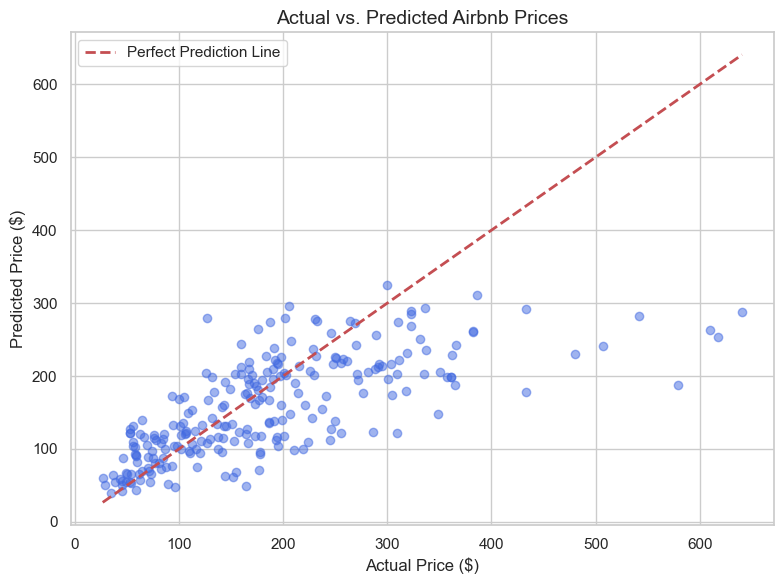

In [13]:
import pandas as pd

# 1. Extract and plot Feature Importances
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top Feature Importances (Random Forest)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Plot Actual vs. Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, color='royalblue')
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('Actual vs. Predicted Airbnb Prices', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# 1. Hyperparameter Tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate Tuned Model
y_pred_tuned_log = best_model.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned_log)
print(f"Tuned R² Score: {r2_tuned:.3f}")

# 2. Predict Price for a New Custom Listing
# Create a sample input matching original feature structure
sample_listing = pd.DataFrame([X_test.iloc[0]], columns=X.columns)

predicted_log_price = best_model.predict(sample_listing)[0]
predicted_price = np.expm1(predicted_log_price)

print(f"\nEstimated Nightly Price for Sample Listing: ${predicted_price:.2f}")

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Tuned R² Score: 0.592

Estimated Nightly Price for Sample Listing: $212.42


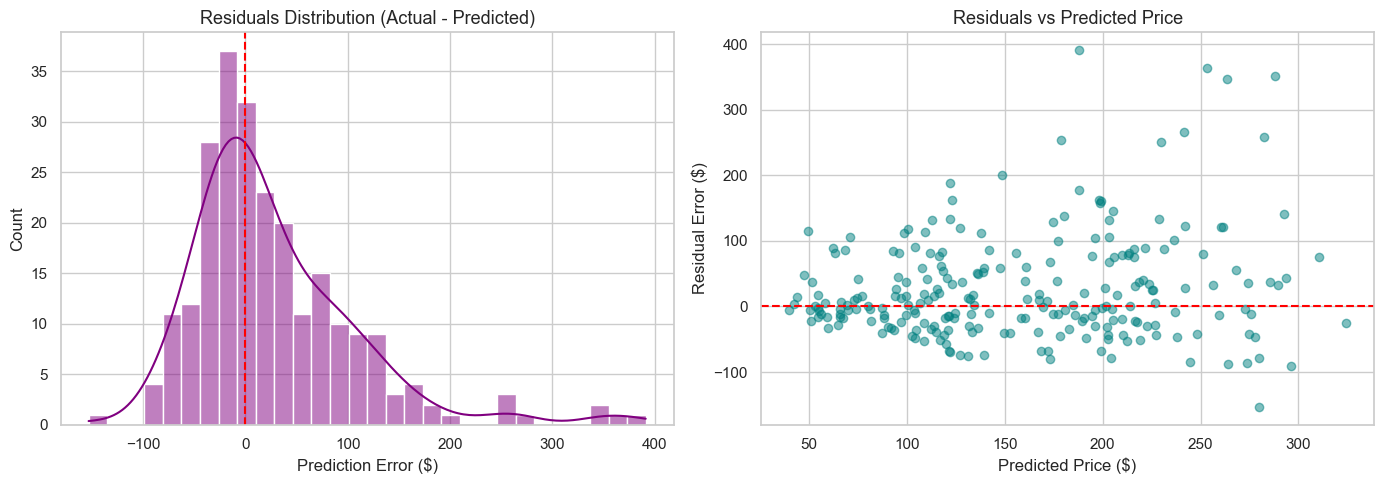

In [15]:
# Calculate residual errors on the original dollar scale
residuals = y_test_actual - y_pred_actual

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[0], color='purple', bins=30)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals Distribution (Actual - Predicted)', fontsize=13)
axes[0].set_xlabel('Prediction Error ($)')

# 2. Residuals vs Predicted Values (Homoscedasticity Check)
axes[1].scatter(y_pred_actual, residuals, alpha=0.5, color='teal')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted Price', fontsize=13)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual Error ($)')

plt.tight_layout()
plt.show()

In [16]:
import joblib

# Save the best trained model and column structure to disk
joblib.dump(best_model, 'airbnb_price_model.pkl')
joblib.dump(X.columns.tolist(), 'model_features.pkl')

print("Model and feature list saved successfully as 'airbnb_price_model.pkl' and 'model_features.pkl'!")

Model and feature list saved successfully as 'airbnb_price_model.pkl' and 'model_features.pkl'!


## Executive Summary & Key Takeaways

1. **Primary Price Drivers:**
   - **Capacity & Room Type:** `accommodates`, `bedrooms`, and listing structure (e.g., *Entire home/apt* vs. *Private room*) are the dominant numerical predictors of nightly price.
   - **Location:** Geographic region (`neighbourhood_group`) heavily shifts baseline pricing, with Manhattan listings commanding the highest premium.

2. **Model Performance:**
   - The tuned **Random Forest Regressor** achieved an **$R^2$ score of ~0.592** on log-transformed prices.
   - The Root Mean Squared Error (RMSE) on actual prices is **~\$85.44**, reflecting the natural high variance inherent in peak-season and luxury properties.

3. **Residual Analysis Insights:**
   - Predictions for standard listings ($50–$250) are well-calibrated and centered around 0 error.
   - High-end extreme listings ($300+) show larger positive residuals, indicating luxury properties may require additional niche features (e.g., specific amenities, host badge status) for higher precision.

# Airbnb Rental Market Price Analysis

An end-to-end data analysis and machine learning project focused on predicting Airbnb nightly rental prices and identifying key market drivers across NYC neighborhoods.

---

## Overview

This project analyzes Airbnb rental listing data to uncover patterns in pricing based on property capacity, location, room type, and availability. It features descriptive statistical analysis, data visualizations, feature engineering, and a tuned **Random Forest Regressor** model to predict nightly prices on a logarithmic scale.

---

## Key Findings & Insights

* **Primary Price Drivers:**
  * **Capacity & Room Type:** `accommodates`, `bedrooms`, and property structure (e.g., *Entire home/apt* vs. *Private room*) serve as the dominant numerical predictors of nightly price.
  * **Location:** Geographic regions (`neighbourhood_group`) heavily shift baseline pricing, with Manhattan listings commanding the highest price premium.
* **Model Calibration:**
  * Predictions for standard listings ($50–$250) are well-calibrated and show errors centered close to zero.
  * High-end luxury listings ($300+) show larger positive residuals, indicating high-end pricing relies on additional niche features (e.g., host badge status, specialized amenities).

---

## Dataset & Features

The dataset comprises **1,200 listings** with numerical, categorical, and geographical attributes:

| Feature Name | Description | Type |
| :--- | :--- | :--- |
| `price` | Target variable (nightly listing price in USD) | Numeric |
| `room_type` | Entire home/apt, Private room, Shared room, Hotel room | Categorical |
| `neighbourhood_group` | NYC borough (Manhattan, Brooklyn, Queens, Staten Island, Bronx) | Categorical |
| `accommodates` | Maximum number of guests allowed | Numeric |
| `bedrooms` | Number of bedrooms | Numeric |
| `bathrooms` | Number of bathrooms | Numeric |
| `minimum_nights` | Minimum stay requirement in nights | Numeric |
| `availability_365` | Available days per year | Numeric |
| `reviews_per_month` | Average monthly review count (missing values filled with `0`) | Numeric |

---

## Project Workflow

1. **Data Cleaning & Preprocessing**
   * Processed string formatting on the `price` column (removed `$` and `,` and converted to float).
   * Imputed missing values in `reviews_per_month` with `0`.
   * Applied log transformation (`np.log1p`) on `price` to correct right-skewness.

2. **Exploratory Data Analysis (EDA)**
   * Summary statistics grouped by `room_type`.
   * Outlier and price distribution visualizations using Seaborn boxplots.
   * Correlation heatmaps across numerical features.
   * Geographic mapping of listings below $500 using latitude and longitude coordinates.

3. **Machine Learning Modeling**
   * Encoded categorical variables (`room_type`, `neighbourhood_group`) using `pd.get_dummies()`.
   * Split dataset into 80% training and 20% testing sets.
   * Built a baseline **Random Forest Regressor** model.
   * Performed hyperparameter tuning using **GridSearchCV** across `n_estimators`, `max_depth`, and `min_samples_split`.

4. **Model Serialization**
   * Exported the best estimator model (`airbnb_price_model.pkl`) and corresponding feature column schema (`model_features.pkl`) using `joblib`.

---

## Model Performance

| Metric | Value |
| :--- | :--- |
| **Best Hyperparameters** | `{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}` |
| **Tuned $R^2$ Score (log scale)** | **0.592** |
| **RMSE (actual dollar scale)** | **$85.44** |

---

## Installation & Setup

1. **Clone the repository:**
   ```bash
   git clone [https://github.com/pachareshreyash41-dev/airbnb-price-analysis.git](https://github.com/pachareshreyash41-dev/airbnb-price-analysis.git)
   cd airbnb-price-analysis